# SVM for classification

Load IRIS dataset, check its contents:


In [2]:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])
#print(iris.data)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Split data into training and testing parts:

In [3]:
from sklearn.model_selection import train_test_split
X=iris.data
y=iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Use a Support Vector Machine for classification:


In [4]:
from sklearn.svm import SVC
SVMmodel=SVC(kernel='linear')
SVMmodel.fit(X_train,y_train)
SVMmodel.get_params()
SVMmodel.score(X_test,y_test)

0.9666666666666667

Let's explore more now.

*   Choose only first two features (columns) of iris.data
*   SVM is in its basic form a 2-class classifier, so eliminate iris.target =2 from the data



In [5]:
X, y = iris.data[:, :2], iris.target

X, y = X[y>0], y[y>0]

Plot scatterplots of targets 0 and 1 and check the separability of the classes:

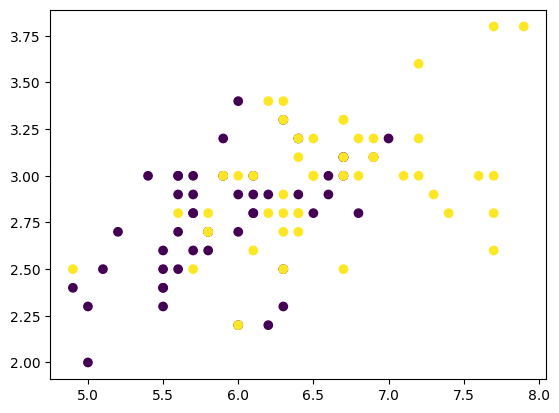

In [6]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

Train and test the SVM classifier, play with regularization parameter C (either use the default value or try e.g. 200)

In [7]:
# Supervised
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

svm_model1 = SVC(kernel='linear')
svm_model1.fit(X_train, y_train)

print("Model accuracy", svm_model1.score(X_test, y_test))

Model accuracy 0.7


Show support vectors in the 2D plot, plot the decision line from equation [w0 w1]*[x0 x1] + b = 0:

(1, 2)
[[1.48152288 0.74063409]]
(1,)
[-11.51849097]


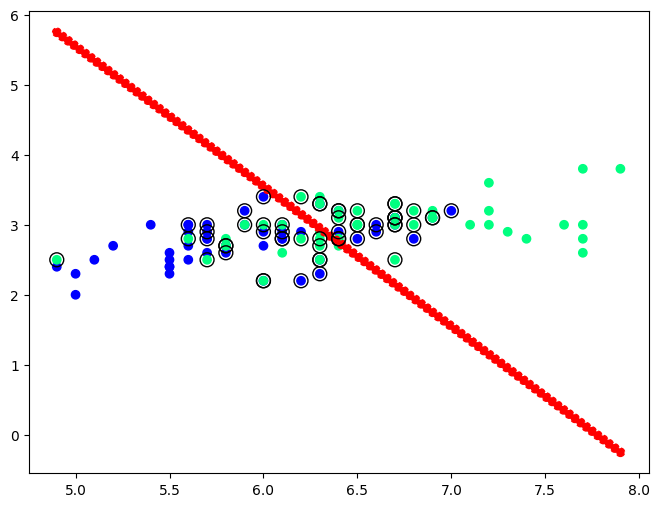

In [8]:
import numpy as np
supvectors=SVMmodel.support_vectors_
# Plot the support vectors here


#Separating line coefficients:
W=svm_model1.coef_
print(W.shape)
print(W)
b=svm_model1.intercept_
print(b.shape)
print(b)
x1 = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 100)
x2 = -(W[0][0]*x1+b)/W[0][1]
plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', label="Données")
plt.scatter(x1, x2, color='red', linestyle='--', label="Frontière de décision")
supvectors = svm_model1.support_vectors_
plt.scatter(supvectors[:, 0], supvectors[:, 1], s=100,
            facecolors='none', edgecolors='k', label="Support vectors")
plt.show()

# Anomaly detection via SVM

Import one-class SVM and generate data (Gaussian blobs in 2D-plane):

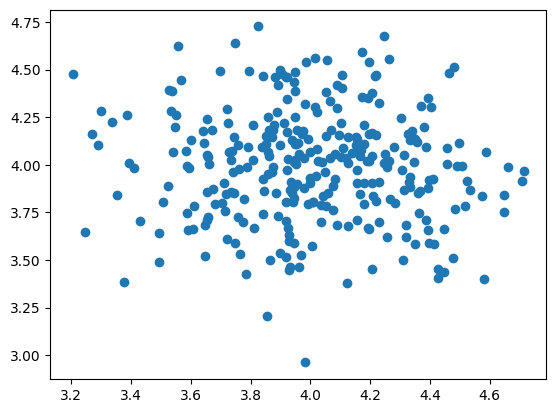

In [9]:
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random

random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))

plt.scatter(x[:,0], x[:,1])
plt.show()



Train one-class SVM and plot the outliers (outputs of prediction being equal to -1)

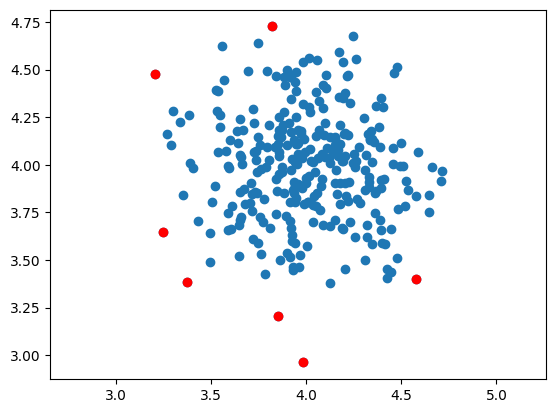

In [10]:
# Unsupervied

SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)


SVMmodelOne.fit(x)
pred = SVMmodelOne.predict(x)
anom_index = where(pred==-1)
values = x[anom_index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()



Plot the support vectors:

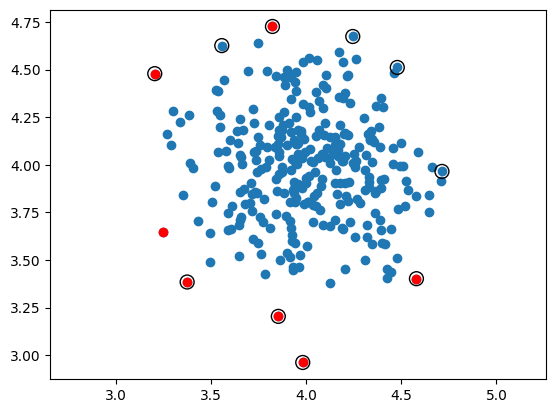

In [11]:
plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
supvectors = SVMmodelOne.support_vectors_
plt.scatter(supvectors[:, 0], supvectors[:, 1], s=100,
            facecolors='none', edgecolors='k', label="support vectors")
plt.show()

What if we want to have a control what is outlier? Use e.g. 5% "quantile" to mark the outliers. Every point with lower score than threshold will be an outlier.

5 % outliers : 8.989098620408397


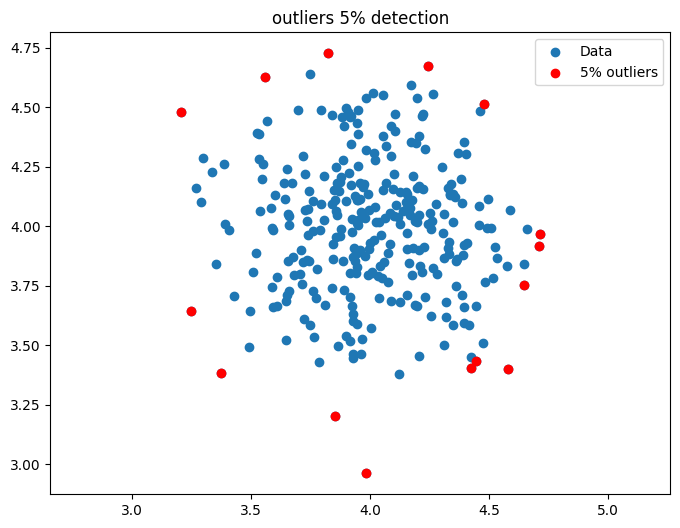

In [12]:
scores = SVMmodelOne.score_samples(x)

thresh = quantile(scores, 0.05)
print(f"5 % outliers : {thresh}")

index = where(scores <= thresh)
values = x[index]

plt.figure(figsize=(8, 6))
plt.scatter(x[:,0], x[:,1], label="Data")
plt.scatter(values[:,0], values[:,1], color='red', label="5% outliers")
plt.title("outliers 5% detection")
plt.legend()
plt.axis('equal')
plt.show()